## INLAB

## TASK-1

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Scale pixel values to 0-1 range
X_train_cnn = X_train_raw.astype('float32') / 255.0
X_test_cnn = X_test_raw.astype('float32') / 255.0

# Add channel dimension (28x28x1) required by 2D Convolution layers
X_train_cnn = np.expand_dims(X_train_cnn, -1)
X_test_cnn = np.expand_dims(X_test_cnn, -1)

# One-hot encode classification targets
y_train_cnn = to_categorical(y_train_raw, 10)
y_test_cnn = to_categorical(y_test_raw, 10)

print("MNIST Image Dataset loaded successfully.")
print(f"  Training features shape: {X_train_cnn.shape} | Test features shape: {X_test_cnn.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST Image Dataset loaded successfully.
  Training features shape: (60000, 28, 28, 1) | Test features shape: (10000, 28, 28, 1)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Design sequential 2D CNN
cnn_model = Sequential([
    # Convolution layer 1: extracts 32 continuous spatial feature maps
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)), # Downsampling dimension reduction
    
    # Convolution layer 2: extracts 64 feature maps
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(), # Flatten 2D feature grids to 1D vector
    
    # Dense classification layers with Dropout regularization
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax') # Softmax activation for multi-class probability outputs
])

print("CNN Architecture successfully established:")
cnn_model.summary()


CNN Architecture successfully established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)               │ (None, 26, 26, 32)    │          320 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 13, 13, 32)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_1 (Conv2D)             │ (None, 11, 11, 64)    │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_1               │ (None, 5, 5, 64)      │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten (Flatten)             │ (None, 1600)          │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 128)           │      204,928 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 10)            │        1,290 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile CNN model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully with Adam optimizer.")

CNN model compiled successfully with Adam optimizer.


In [6]:
# Train the model
history_cnn = cnn_model.fit(
    X_train_cnn, 
    y_train_cnn, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

print("\nCNN training complete.")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.9406 - loss: 0.1946 - val_accuracy: 0.9860 - val_loss: 0.0463
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9809 - loss: 0.0612 - val_accuracy: 0.9873 - val_loss: 0.0425
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9867 - loss: 0.0432 - val_accuracy: 0.9913 - val_loss: 0.0281
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9894 - loss: 0.0334 - val_accuracy: 0.9908 - val_loss: 0.0290
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9922 - val_loss: 0.0296

CNN training complete.


CNN Holdout Test Accuracy: 99.24%

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
--- Classification Performance Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



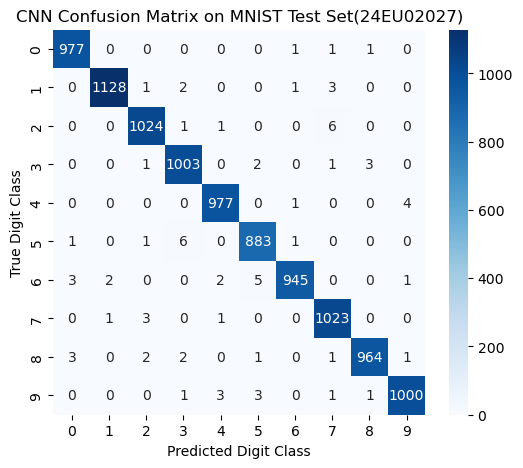

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

# Predict target classes
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("--- Classification Performance Report ---")
print(classification_report(y_test_raw, y_pred_classes))

# Plot confusion matrix
cm = confusion_matrix(y_test_raw, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("CNN Confusion Matrix on MNIST Test Set(24EU02027)")
plt.xlabel("Predicted Digit Class")
plt.ylabel("True Digit Class")
plt.show()

## TASK-2

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic sine wave sequence
t_points = np.linspace(0, 100, 1000)
series_data = np.sin(t_points)

# Create sliding window function to format input-output sequence structures
def create_sliding_windows(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# Lookback window set to 20 steps
lookback_steps = 20
X_raw, y_raw = create_sliding_windows(series_data, lookback_steps)

# Reshape input X to fit 3D requirements: [samples, time_steps, features]
X_seq = np.expand_dims(X_raw, -1)
y_seq = y_raw

# Train-Test Split (80% train, 20% test)
split_idx = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print("Time Series Sequence Prepared:")
print(f"  Training features shape: {X_train_seq.shape} | Test features shape: {X_test_seq.shape}")

Time Series Sequence Prepared:
  Training features shape: (784, 20, 1) | Test features shape: (196, 20, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Construct LSTM Network for sequence prediction
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1) # Linear continuous numeric output node
])

print("Sequential LSTM Architecture established:")
lstm_model.summary()


Sequential LSTM Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm (LSTM)                   │ (None, 50)            │       10,400 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 1)             │           51 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile LSTM model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM model
history_lstm = lstm_model.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

print("\nModel training complete.")


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.4276 - val_loss: 0.2291
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1270 - val_loss: 0.0391
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0093 - val_loss: 0.0012
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011 - val_loss: 4.0333e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.6130e-04 - val_loss: 2.7174e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.0147e-04 - val_loss: 2.0019e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.5571e-04 - val_loss: 1.2114e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.1732e-04 - val_loss: 9.1289e-05
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.9358e-05 - val_loss: 5.9331e-05
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.5813e-05 - val_loss: 5.1377e-05
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 4.0685e-05 - val_loss: 3.3365e-05
Epo

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


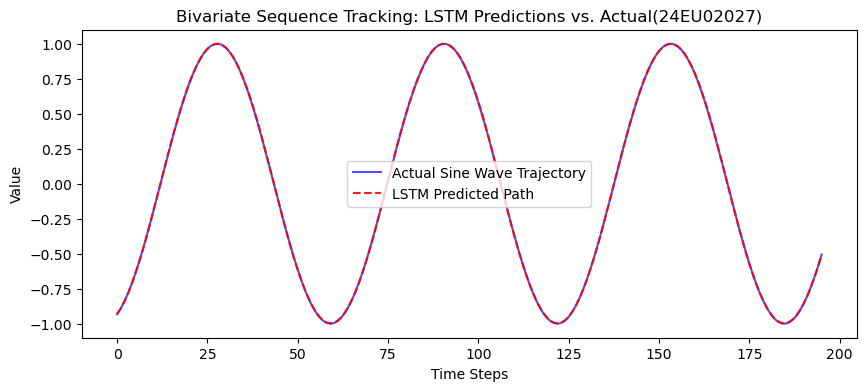

In [11]:
# Predict sequences on the test partition
lstm_predictions = lstm_model.predict(X_test_seq)

# Plot actual trajectory vs predictions
plt.figure(figsize=(10, 4))
plt.plot(y_test_seq, label='Actual Sine Wave Trajectory', color='blue', alpha=0.7)
plt.plot(lstm_predictions, label='LSTM Predicted Path', color='red', linestyle='--', alpha=0.9)
plt.title("Bivariate Sequence Tracking: LSTM Predictions vs. Actual(24EU02027)")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute error metrics on predictions
mae_lstm = mean_absolute_error(y_test_seq, lstm_predictions)
mse_lstm = mean_squared_error(y_test_seq, lstm_predictions)
r2_lstm = r2_score(y_test_seq, lstm_predictions)

print("--- LSTM Quantitative Performance ---")
print(f"Mean Absolute Error (MAE): {mae_lstm:.6f}")
print(f"Mean Squared Error (MSE):  {mse_lstm:.6f}")
print(f"Coefficient of Determination (R2): {r2_lstm:.6f}")


--- LSTM Quantitative Performance ---
Mean Absolute Error (MAE): 0.002213
Mean Squared Error (MSE):  0.000007
Coefficient of Determination (R2): 0.999986


## TASK-3

In [13]:
from tensorflow.keras.layers import SimpleRNN

# Construct SimpleRNN Model to act as a comparative baseline
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train SimpleRNN for 15 epochs
history_rnn = rnn_model.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.3049 - val_loss: 0.0250
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0093 - val_loss: 0.0017
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016 - val_loss: 9.4122e-04
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.7207e-04 - val_loss: 6.7751e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.1743e-04 - val_loss: 5.6312e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.9289e-04 - val_loss: 6.9369e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.6494e-04 - val_loss: 4.3399e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.1801e-04 - val_loss: 4.4009e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4882e-04 - val_loss: 3.5814e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.4212e-04 - val_loss: 2.8105e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.0169e-04 - val_loss: 2.7268

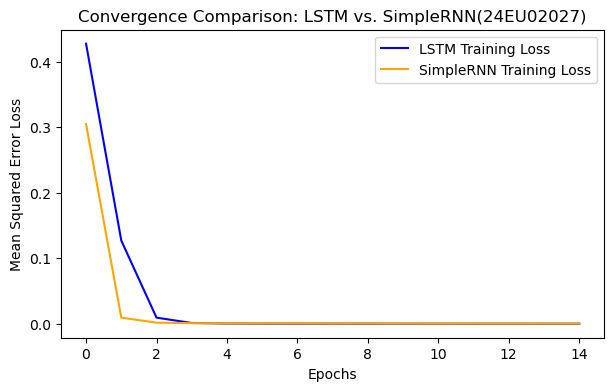

In [15]:
# Plot training loss comparison
plt.figure(figsize=(7, 4))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss', color='blue')
plt.plot(history_rnn.history['loss'], label='SimpleRNN Training Loss', color='orange')
plt.title("Convergence Comparison: LSTM vs. SimpleRNN(24EU02027)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.show()

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Implement dynamic learning rate reduction and early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Fit LSTM with optimization callbacks for robust convergence
tuned_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
tuned_lstm.compile(optimizer='adam', loss='mean_squared_error')

history_tuned = tuned_lstm.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=30, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stop, reduce_lr], 
    verbose=1
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.3555 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1055 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0078 - val_loss: 9.0734e-04 - learning_rate: 0.0010
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.5301e-04 - val_loss: 4.2826e-04 - learning_rate: 0.0010
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.4777e-04 - val_loss: 2.8858e-04 - learning_rate: 0.0010
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.5392e-04 - val_loss: 2.2324e-04 - learning_rate: 0.0010
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.1202e-04 - val_loss: 1.6203e-04 - learning_rate: 0.0010
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4681e-04 - val_loss: 1.2629e-04 - learning_rate: 0.0010
Epoch 9/30
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1141e-04
Epoch 9: Reduc

In [17]:
import pandas as pd

# Generate predictions across models
rnn_preds = rnn_model.predict(X_test_seq)
tuned_preds = tuned_lstm.predict(X_test_seq)

# Metrics calculation helper
def get_metrics(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), r2_score(y_true, y_pred)]

rnn_m = get_metrics(y_test_seq, rnn_preds)
lstm_m = get_metrics(y_test_seq, lstm_predictions)
tuned_m = get_metrics(y_test_seq, tuned_preds)

# Compile comparison DataFrame
comparison_table = pd.DataFrame(
    data=[rnn_m, lstm_m, tuned_m],
    columns=['MAE', 'MSE', 'R2_Score'],
    index=['Baseline SimpleRNN', 'Standard LSTM', 'Tuned/Optimized LSTM']
)
print("--- Quantitative Performance Comparison ---")
print(comparison_table.round(6))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
--- Quantitative Performance Comparison ---
                           MAE       MSE  R2_Score
Baseline SimpleRNN    0.010486  0.000152  0.999697
Standard LSTM         0.002213  0.000007  0.999986
Tuned/Optimized LSTM  0.005767  0.000042  0.999917


In [18]:
print("--- Deep Learning Performance Insights ---")
print("1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.")
print("2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.")
print("3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.")

--- Deep Learning Performance Insights ---
1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.
2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.
3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.


## POSTLAB

## CNN

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9335 - loss: 0.2128 - val_accuracy: 0.9833 - val_loss: 0.0506
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9760 - loss: 0.0809 - val_accuracy: 0.9877 - val_loss: 0.0401
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9818 - loss: 0.0586 - val_accuracy: 0.9903 - val_loss: 0.0379
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9855 - loss: 0.0474 - val_accuracy: 0.9908 - val_loss: 0.0342
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9873 - loss: 0.0400 - val_accuracy: 0.9908 - val_loss: 0.0352
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9916 - loss: 0.0238
CNN Test Accuracy: 99.1599977016449 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Actual: 7
Predicted: 7
Actual: 2
Predicted: 2
Actual: 1
Predicted: 1
Actual: 0
Predicted: 0
Actual: 4
Predicted: 4


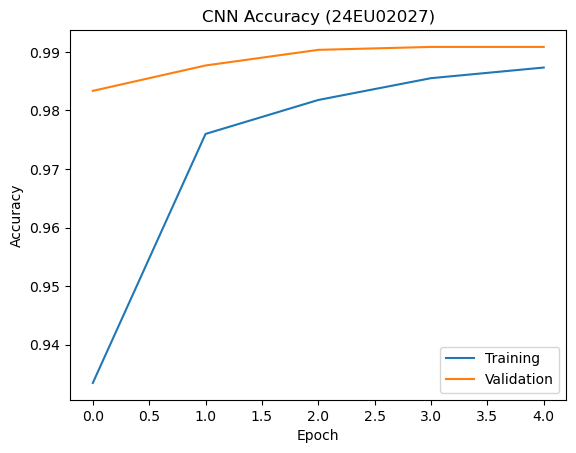

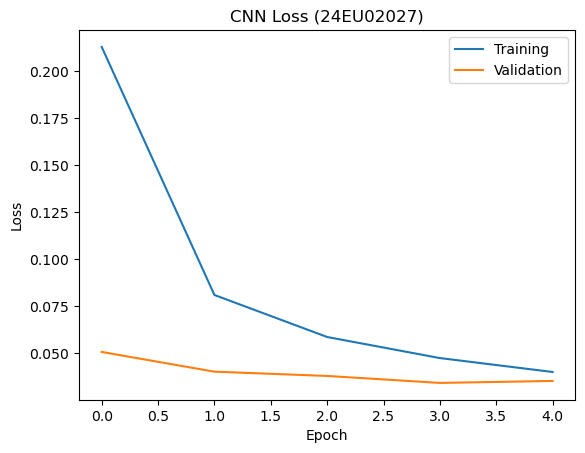

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# CNN model
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
cnn.summary()

# Train
history = cnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Test
loss, accuracy = cnn.evaluate(X_test, y_test)

print("CNN Test Accuracy:", accuracy * 100, "%")

# Prediction
pred = cnn.predict(X_test[:5])

for i in range(5):
    print("Actual:", y_test[i])
    print("Predicted:", pred[i].argmax())

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (24EU02027)")
plt.legend(["Training", "Validation"])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (24EU02027)")
plt.legend(["Training", "Validation"])
plt.show()

## RNN

Training data shape: 25000
Testing data shape: 25000
X_train shape: (25000, 200)
X_test shape: (25000, 200)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.5270 - loss: 0.6903 - val_accuracy: 0.4990 - val_loss: 0.6929
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.5788 - loss: 0.6725 - val_accuracy: 0.6222 - val_loss: 0.6508
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.6899 - loss: 0.5980 - val_accuracy: 0.7214 - val_loss: 0.5754
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.6783 - loss: 0.6031 - val_accuracy: 0.5136 - val_loss: 0.6884
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.5881 - loss: 0.6544 - val_accuracy: 0.5956 - val_loss: 0.6603

RNN Test Accuracy: 58.67599844932556 %

Predictions:
Actual: Negative
Predicted: Negative

Actual: Positive
Predicted: Positive

Actual: Positive
Predicted: Positive

Actual: Negative
Predicted: Negative

Actual: Positive
Predicted: Negative



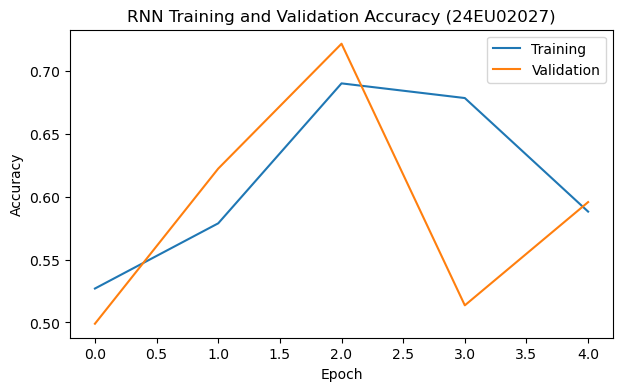

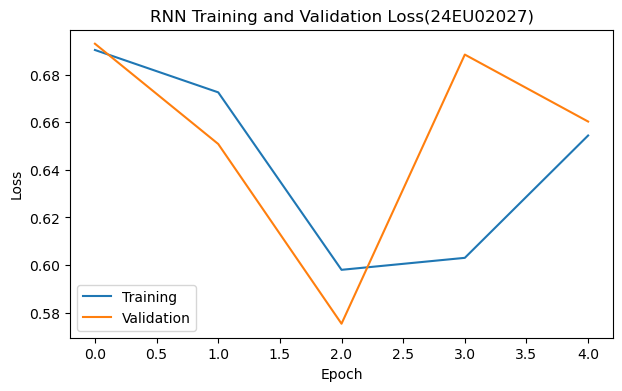

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
vocab_size = 10000
max_length = 200

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training data shape:", len(X_train))
print("Testing data shape:", len(X_test))

# Pad sequences
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Create RNN model
rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

# Compile model
rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model
rnn.summary()

# Train model
history = rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate model
loss, accuracy = rnn.evaluate(X_test, y_test, verbose=0)

print("\nRNN Test Accuracy:", accuracy * 100, "%")

# Prediction
pred = rnn.predict(X_test[:5], verbose=0)

print("\nPredictions:")

for i in range(5):

    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if pred[i][0] >= 0.5 else "Negative"

    print("Actual:", actual)
    print("Predicted:", predicted)
    print()

# Accuracy graph
plt.figure(figsize=(7, 4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy (24EU02027)")
plt.legend(["Training", "Validation"])
plt.show()

# Loss graph
plt.figure(figsize=(7, 4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss(24EU02027)")
plt.legend(["Training", "Validation"])
plt.show()